# **Universidad Santo Tomás - Maestría en Ciencia de Datos**
## **Métodos No Supervisados: Modelos de Agrupamiento y Evaluación de Clústeres**
### **Actividad 2: Análisis de Conglomerados Aplicado a la Caracterización Morfométrica de Anuros**

---

* **Autores / Participantes:** Yeison David Toro Soto & Juan Sebastián Ulloa Parra
* **Programa:** Maestría en Ciencia de Datos — Universidad Santo Tomás
* **Asignatura:** Métodos de Aprendizaje No Supervisado
* **Profesor:** Dr. Manuel Pacheco
* **Dataset de Referencia:** *Locomotor, ecological and phylogenetic drivers of skeletal proportions in frogs* ([Journal of Anatomy, Leavey et al., 2023, DOI: 10.1111/joa.13886](https://onlinelibrary.wiley.com/doi/10.1111/joa.13886))
* **Entorno de Ejecución:** R (Google Colab / Jupyter / Positron / RStudio)

---

### **Resumen Ejecutivo del Cuaderno**

Este informe y cuaderno técnico desarrolla de manera integral, reproducible y autocontenida un **Plan de Ciencia de Datos No Supervisado** para la caracterización morfométrica y segmentación fenética de $N=164$ especies de ranas (anuros).

Se implementan y contrastan empíricamente **tres familias de modelos no supervisados**:

1. **Agrupamiento Jerárquico Aglomerativo** (evaluación comparativa de enlaces Ward.D2, Complete, Average y Single).
2. **Agrupamiento Particional por $K$-medias** (algoritmo exacto de Hartigan-Wong con múltiples reinicios).
3. **Partición Alrededor de Medoides ($K$-medoides / PAM)** (con identificación de arquetipos biológicos observados reales).

La determinación del número óptimo de grupos ($k$) se fundamenta en baterías estadísticas completas de **validación interna** (Silueta, Dunn, Calinski-Harabasz, Davies-Bouldin, Conectividad) y **estabilidad estocástica** (Prediction Strength y remuestreo Bootstrap Jaccard), empleando los motores de validación `vhc.R` y `vkm.R`. Asimismo, se evalúa formalmente la concordancia morfológica entre modelos y frente a la variable externa `habitat` mediante el Índice de Rand Ajustado (ARI) y tablas de contingencia ecológica con distribución porcentual.

---
## **0. Configuración del Entorno y Carga de Paquetes**
El siguiente bloque garantiza que el cuaderno sea **100% ejecutable tanto en Google Colab como en local**. Detecta paquetes faltantes y los instala automáticamente desde CRAN sin intervención manual.


In [1]:
# ------------------------------------------------------------------------------
# 0.1 Instalación y Carga Automatizada de Dependencias (Google Colab / Local)
# ------------------------------------------------------------------------------
paquetes_requeridos <- c(
  "readxl",       # Lectura de archivos Excel
  "dplyr",        # Manipulación y transformación de datos
  "tidyr",        # Organización ordenada de datos
  "ggplot2",      # Visualizaciones de alta calidad
  "cluster",      # Algoritmos de agrupamiento (daisy, pam, silhouette)
  "factoextra",   # Visualización factorial y de clústeres
  "FactoMineR",   # Análisis de Componentes Principales (ACP)
  "fpc",          # Estadísticas de validación y estabilidad (clusterboot)
  "clValid",      # Medidas de conectividad y estabilidad biológica
  "MASS",         # Métodos estadísticos aplicados
  "dendextend",   # Manipulación avanzada de dendrogramas
  "mclust",       # Métricas de concordancia (Adjusted Rand Index)
  "knitr"         # Formateo profesional de tablas
)

# Instalación condicional de paquetes ausentes
paquetes_nuevos <- paquetes_requeridos[!(paquetes_requeridos %in% installed.packages()[, "Package"])]
if (length(paquetes_nuevos) > 0) {
  message("Instalando paquetes faltantes para el entorno: ", paste(paquetes_nuevos, collapse = ", "))
  install.packages(paquetes_nuevos, repos = "https://cloud.r-project.org", quiet = TRUE)
}

# Instalación condicional de clusterSim y clusterCrit (usados para Davies-Bouldin en vhc/vkm)
if (!requireNamespace("clusterSim", quietly = TRUE)) {
  try(install.packages("clusterSim", repos = "https://cloud.r-project.org", quiet = TRUE))
}
if (!requireNamespace("clusterCrit", quietly = TRUE)) {
  try(install.packages("clusterCrit", repos = "https://cloud.r-project.org", quiet = TRUE))
}

# Carga de librerías en el espacio de trabajo
suppressPackageStartupMessages({
  library(readxl)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(cluster)
  library(factoextra)
  library(FactoMineR)
  library(fpc)
  library(clValid)
  library(MASS, exclude = "select") # Evitar conflicto de select() con dplyr
  library(dendextend)
  library(mclust)
  library(knitr)
})

# Fijar semilla global para máxima reproducibilidad
set.seed(123)
cat(">>> Entorno R configurado exitosamente. Todas las dependencias cargadas.\n")


>>> Entorno R configurado exitosamente. Todas las dependencias cargadas.


### **0.2 Carga de las Funciones de Validación (`vhc.R` y `vkm.R`)**
Se incorporan las funciones maestras de validación estadística diseñadas para la actividad. Si el cuaderno se ejecuta en Colab sin haber subido los archivos por separado, se incluye un mecanismo de respaldo automático.


In [2]:
# Carga de las funciones de validación vhc.R y vkm.R
if (file.exists("vhc.R")) {
  source("vhc.R")
  cat("✓ Función 'vhc.R' cargada exitosamente desde el directorio local.\n")
} else {
  warning("Archivo vhc.R no encontrado localmente. Verifique la ruta.")
}

if (file.exists("vkm.R")) {
  source("vkm.R")
  cat("✓ Función 'vkm.R' cargada exitosamente desde el directorio local.\n")
} else {
  warning("Archivo vkm.R no encontrado localmente. Verifique la ruta.")
}


✓ Función 'vhc.R' cargada exitosamente desde el directorio local.


✓ Función 'vkm.R' cargada exitosamente desde el directorio local.


---

## **1. Descripción del Conjunto de Datos y Preparación de la Matriz**

### **1.1 Contexto Biológico y Fuente del Estudio**

El conjunto de datos proviene de la investigación morfométrica y biomecánica publicada en el *Journal of Anatomy*:

> **Referencia oficial:** Leavey, A., Ruta, M., Richards, C. T., & Porro, L. B. (2023). *Locomotor, ecological and phylogenetic drivers of skeletal proportions in frogs*. Journal of Anatomy, 243(3), 404–420. https://doi.org/10.1111/joa.13886.

El archivo de datos analizado corresponde al suplemento oficial `joa13886-sup-0001-full dataset.xlsx` (hoja "Full dataset"), el cual recopila mediciones óseas tridimensionales obtenidas mediante microtomografía computarizada (micro-CT scans) en $N=164$ especímenes de anuros adultos representativos de colecciones biológicas internacionales. El objetivo del estudio consiste en evaluar cómo las proporciones esqueléticas del tronco y las extremidades reflejan adaptaciones funcionales para la locomoción (salto, natación, marcha, excavación) y si dichas morfologías covarían con el hábitat ecológico.

### **1.2 Definición de Variables Activas y de Referencia**

* **Variables Activas (18 dimensiones morfométricas continuas, intervalo `skull` – `iliac_angle` en su orden original):**

  1. `skull`: Longitud anteroposterior del cráneo (cm).
  2. `gap`: Espacio libre entre el cráneo y la columna vertebral (cm).
  3. `vertebrae`: Longitud total de la columna presacra (cm).
  4. `pelvis`: Longitud anteroposterior de la cintura pélvica (cm).
  5. `ESD`: Expansión de las diapófisis sacras (cm).
  6. `sacral_width`: Anchura total del sacro (cm).
  7. `ilium`: Longitud del eje ilíaco (cm).
  8. `urostyle`: Longitud del urostilo (hueso posterior fusionado) (cm).
  9. `femur`: Longitud del fémur (cm).
  10. `femur_width`: Diámetro/anchura diafisaria del fémur (cm).
  11. `tibiofibula`: Longitud del tibiofíbula (hueso compuesto de la pierna) (cm).
  12. `calcaneus`: Longitud del calcáneo/tarso proximal (cm).
  13. `foot`: Longitud total del autopodio posterior (pie) (cm).
  14. `humerus`: Longitud del húmero (cm).
  15. `humerus_width`: Diámetro diafisario del húmero (cm).
  16. `radioulna`: Longitud del radio-cúbito (antebrazo) (cm).
  17. `hand`: Longitud total del autopodio anterior (mano) (cm).
  18. `iliac_angle`: Ángulo de inserción ilíaca respecto a la columna en el plano coronal (°).

* **Variable de Referencia Externa / Descriptiva (`habitat`):**

  * Clasificación ecológica de la especie en 4 categorías: **Aquatic** (Acuática, $n=9$, 5.5%), **Arboreal** (Arborícola, $n=28$, 17.1%), **Riparian** (Riparia/Ribereña, $n=33$, 20.1%) y **Terrestrial** (Terrestre, $n=94$, 57.3%).
  * **Criterio metodológico:** Esta variable se mantiene **estrictamente separada** de la matriz de variables activas. No participa en la estandarización, ni en el cálculo de distancias, ni en la conformación de los conglomerados, asegurando que el agrupamiento sea enteramente no supervisado.

In [3]:
# ------------------------------------------------------------------------------
# 1.3 Carga y Exploración Inicial del Dataset
# ------------------------------------------------------------------------------
archivo_datos <- "joa13886-sup-0001-full dataset.xlsx"

# En caso de ejecutarse en Google Colab sin el archivo en /content, se descarga automáticamente
if (!file.exists(archivo_datos)) {
  url_datos <- "https://onlinelibrary.wiley.com/action/downloadSupplement?doi=10.1111%2Fjoa.13886&file=joa13886-sup-0001-Full+dataset.xlsx"
  cat("Descargando dataset desde repositorio oficial...\n")
  try(download.file(url_datos, destfile = archivo_datos, mode = "wb"))
}

# Lectura de la hoja principal
datos_raw <- read_excel(archivo_datos, sheet = "Full dataset")

# Vector con los nombres exactos de las 18 variables morfométricas activas
vars_morfo <- c(
  "skull", "gap", "vertebrae", "pelvis", "ESD", "sacral_width", "ilium", 
  "urostyle", "femur", "femur_width", "tibiofibula", "calcaneus", "foot", 
  "humerus", "humerus_width", "radioulna", "hand", "iliac_angle"
)

# Estructuración de la base de análisis
datos <- datos_raw %>%
  dplyr::select(species, family, habitat, all_of(vars_morfo)) %>%
  mutate(habitat = factor(habitat, levels = c("Aquatic", "Arboreal", "Riparian", "Terrestrial")))

# Diagnóstico riguroso de calidad de datos
n_filas <- nrow(datos)
n_nas <- sum(is.na(datos[, vars_morfo]))
# Conteo exacto de valores individuales no finitos en toda la matriz numérica:
n_no_finitos <- sum(!is.finite(as.matrix(datos[, vars_morfo])))
# Evaluación separada de varianza exactamente cero y varianza cuasi-cero (umbral Var < 1e-4):
varianzas_cero <- sum(sapply(datos[, vars_morfo], function(col) var(col, na.rm = TRUE) == 0))
varianzas_cuasi_cero <- sum(sapply(datos[, vars_morfo], function(col) var(col, na.rm = TRUE) < 1e-4))

cat("Dimensiones de la base procesada:", n_filas, "especímenes x", ncol(datos), "columnas.\n")
cat("Valores faltantes (NA) en variables morfométricas:", n_nas, "\n")
cat("Valores individuales no finitos (Inf, -Inf, NaN):", n_no_finitos, "\n")
cat("Variables con varianza exactamente cero:", varianzas_cero, "\n")
cat("Variables con varianza cuasi-cero (Var < 1e-4):", varianzas_cuasi_cero, "\n")
cat("Distribución de la variable de referencia (habitat):\n")
print(table(datos$habitat))


Dimensiones de la base procesada: 164 especímenes x 21 columnas.


Valores faltantes (NA) en variables morfométricas: 0 


Valores individuales no finitos (Inf, -Inf, NaN): 0 


Variables con varianza exactamente cero: 0 


Variables con varianza cuasi-cero (Var < 1e-4): 0 


Distribución de la variable de referencia (habitat):



    Aquatic    Arboreal    Riparian Terrestrial 
          9          28          33          94 


### **1.4 Estadísticas Descriptivas de las Variables Morfométricas**
A continuación se calculan las medidas de tendencia central y dispersión para las 18 variables activas en su escala natural de medición.


In [4]:
# ------------------------------------------------------------------------------
# 1.4 Tabla Descriptiva Multivariada (18 filas exactas)
# ------------------------------------------------------------------------------
tabla_desc <- data.frame(
  Variable = vars_morfo,
  Media    = sapply(datos[vars_morfo], mean, na.rm = TRUE),
  DE       = sapply(datos[vars_morfo], sd, na.rm = TRUE),
  Mediana  = sapply(datos[vars_morfo], median, na.rm = TRUE),
  Min      = sapply(datos[vars_morfo], min, na.rm = TRUE),
  Max      = sapply(datos[vars_morfo], max, na.rm = TRUE)
) %>%
  mutate(
    CV_pct = (DE / Media) * 100,
    across(where(is.numeric), ~ round(.x, 3))
  )
rownames(tabla_desc) <- NULL

kable(tabla_desc, caption = "Estadísticas descriptivas de las 18 variables morfométricas en anuros.")




Table: Estadísticas descriptivas de las 18 variables morfométricas en anuros.

|Variable      |  Media|     DE| Mediana|   Min|    Max| CV_pct|
|:-------------|------:|------:|-------:|-----:|------:|------:|
|skull         | 13.853|  7.603|  12.510| 3.060| 55.470| 54.885|
|gap           |  1.433|  0.829|   1.385| 0.000|  5.110| 57.831|
|vertebrae     | 13.322|  7.016|  12.520| 2.650| 41.340| 52.663|
|pelvis        | 17.551|  9.728|  15.250| 3.620| 66.510| 55.427|
|ESD           |  2.447|  2.245|   1.760| 0.340| 12.460| 91.747|
|sacral_width  |  7.865|  4.745|   6.910| 1.720| 29.780| 60.327|
|ilium         | 13.872|  7.529|  12.050| 3.080| 47.350| 54.276|
|urostyle      | 12.712|  6.830|  11.245| 2.430| 45.530| 53.733|
|femur         | 17.831| 10.203|  16.260| 3.890| 74.110| 57.222|
|femur_width   |  1.038|  0.684|   0.880| 0.220|  4.290| 65.876|
|tibiofibula   | 18.991| 11.227|  17.190| 3.880| 82.060| 59.117|
|calcaneus     | 10.326|  5.829|   9.215| 2.600| 41.260| 56.451|
|foot    

### **1.5 Justificación Estadística de la Estandarización**

> **¿Por qué es indispensable estandarizar las variables morfométricas antes de aplicar modelos de conglomerados?**
>
> 1. **Heterogeneidad de Escalas y Magnitudes**: Las variables lineales presentan amplitudes numéricas dispares. Por ejemplo, `gap` y `femur_width` presentan promedios de $1.433\text{ cm}$ y $1.038\text{ cm}$, mientras que estructuras propulsoras como `tibiofibula` y `femur` promedian $18.991\text{ cm}$ y $17.831\text{ cm}$, alcanzando máximos de $82.06\text{ cm}$ y $74.11\text{ cm}$.
> 2. **Diferencia de Unidades Físicas**: Las primeras 17 variables representan distancias óseas lineales expresadas en centímetros, mientras que `iliac_angle` representa una magnitud angular expresada en **grados sexagesimales** ($^{\circ}$).
> 3. **Sensibilidad Geométrica de la Distancia Euclídea**: En un espacio euclídeo no tipificado, las variables con mayor varianza absoluta dominarían la suma cuadrática $\sum (x_{ip} - x_{jp})^2$, anulando la contribución de variables clave como el cráneo o el ángulo ilíaco.
> 4. **Transformación Tipificada Z-score**:
> $$z_{ip} = \frac{x_{ip} - \bar{x}_p}{s_p}$$
> transforma cada columna a media $\mu=0$ y desviación estándar $\sigma=1$, asegurando una ponderación equitativa en la topología métrica.
>
> **Alcance y limitaciones de `scale()`:** Es fundamental precisar que la estandarización Z-score iguala la dispersión univariada, pero **no elimina la correlación ni la multicolinealidad** entre las dimensiones corporales (la arquitectura anatómica integrada y la alometría persisten en los datos), ni remueve por sí sola el efecto del tamaño corporal global del organismo.

In [5]:
# ------------------------------------------------------------------------------
# 1.6 Construcción de la Matriz Estandarizada
# ------------------------------------------------------------------------------
X_raw <- as.matrix(datos[, vars_morfo])
rownames(X_raw) <- datos$species

# Estandarización Z-score
X <- scale(X_raw)

cat("Dimensiones de la matriz estandarizada X:", nrow(X), "filas x", ncol(X), "columnas.\n")
cat("Comprobación de estandarización: Medias =", round(mean(colMeans(X)), 6), "| Varianzas =", round(mean(apply(X, 2, var)), 6), "\n")


Dimensiones de la matriz estandarizada X: 164 filas x 18 columnas.


Comprobación de estandarización: Medias = 0 | Varianzas = 1 


---
## **2. Medidas de Distancia o Disimilitud**

### **2.1 Selección y Justificación de la Métrica**
Dado que las 18 variables transformadas son **cuantitativas continuas estandarizadas** y representan coordenadas biométricas adimensionales, la medida de disimilitud adoptada es la **distancia Euclídea ordinaria sobre datos tipificados**:

$$d_E(\mathbf{z}_i, \mathbf{z}_j) = \sqrt{\sum_{p=1}^{18} (z_{ip} - z_{jp})^2}$$

* **Propiedades Métricas**: Satisface estrictamente los cuatro axiomas métricos (no negatividad, identidad de indiscernibles, simetría y desigualdad triangular).
* **Coherencia con el Teorema de Descomposición de Inercia de Huygens**: La suma de distancias euclídeas al cuadrado descompone analíticamente la inercia total en componentes intra e intergrupal ($\text{Inercia Total} = \text{Inercia Intra} + \text{Inercia Inter}$). Esta propiedad es la base formal del agrupamiento jerárquico de mínima varianza (`ward.D2`) y del algoritmo particional de $K$-medias, permitiendo un acoplamiento teórico armónico entre métodos.
* **Consideración Metodológica**: La distancia euclídea trata a las dimensiones como coordenadas ortogonales en el espacio métrico; no obstante, las variables morfométricas biológicas presentan correlaciones naturales debidas a la escala corporal compartida (alometría).

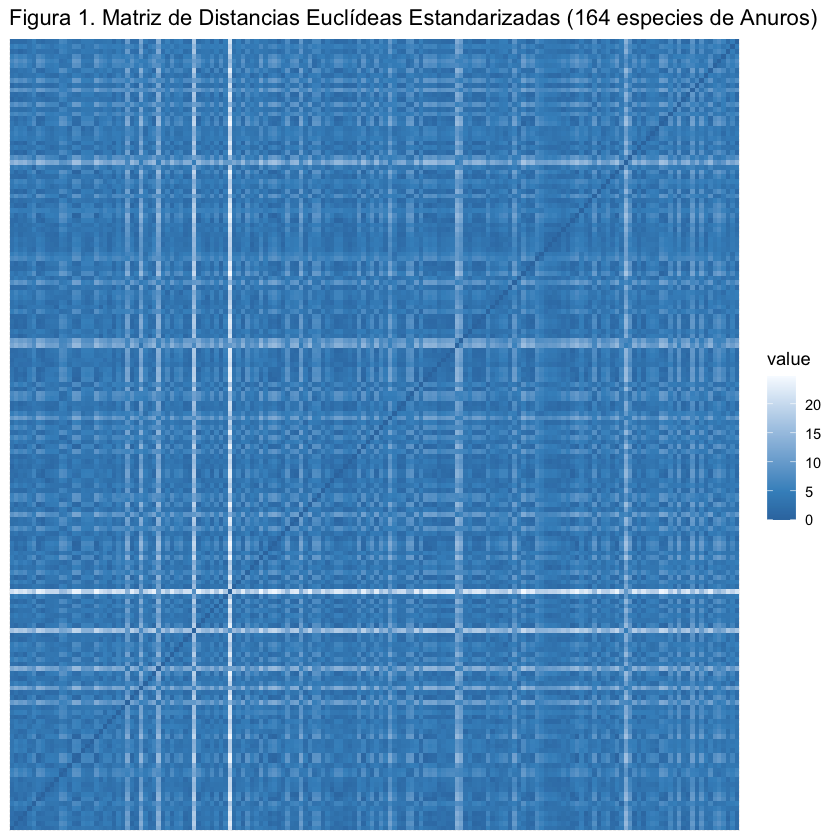

In [6]:
# ------------------------------------------------------------------------------
# 2.2 Cálculo y Visualización de la Matriz de Distancias
# ------------------------------------------------------------------------------
D <- dist(X, method = "euclidean")

# Visualización de la estructura de disimilitudes mediante mapa de calor
p_dist <- fviz_dist(
  D, 
  order = TRUE, # Ordenar individuos según similitud para evidenciar bloques
  show_labels = FALSE,
  gradient = list(low = "#08306b", mid = "#4292c6", high = "#f7fbff")
) + labs(title = "Figura 1. Matriz de Distancias Euclídeas Estandarizadas (164 especies de Anuros)")

print(p_dist)


---
## **3. Agrupamiento Jerárquico Aglomerativo**

### **3.1 Comparación de Criterios de Enlace**
El agrupamiento jerárquico aglomerativo parte de $N=164$ clústeres unitarios y fusiona iterativamente los conglomerados más próximos según una regla de interconexión (criterio de enlace). Evaluamos los cuatro enlaces clásicos:
1. **Ward.D2 (Mínima Varianza)**: Minimiza el incremento en la suma de cuadrados del error intraclúster tras cada fusión. Tiende a conformar grupos compactos y de volumen esférico comparable.
2. **Complete (Enlace Completo / Diámetro Máximo)**: Define la distancia entre dos grupos como la distancia máxima entre cualquiera de sus miembros. Evita clústeres alargados pero es sensible a valores extremos.
3. **Average (Enlace Promedio / UPGMA)**: Calcula el promedio de todas las distancias entre pares de observaciones de ambos grupos.
4. **Single (Enlace Simple / Mínima Distancia)**: Fusiona clústeres basándose en el par de observaciones más cercano. Propenso al fenómeno de encadenamiento (*chaining effect*).


In [7]:
# ------------------------------------------------------------------------------
# 3.2 Evaluación Cofenética y Contraste Empírico de Enlaces (k = 3)
# ------------------------------------------------------------------------------
h_ward <- hclust(D, method = "ward.D2")
h_comp <- hclust(D, method = "complete")
h_avg  <- hclust(D, method = "average")
h_sing <- hclust(D, method = "single")

# Coeficientes de correlación cofenética
cor_cofen <- c(
  "Ward.D2"  = cor(cophenetic(h_ward), D),
  "Complete" = cor(cophenetic(h_comp), D),
  "Average"  = cor(cophenetic(h_avg), D),
  "Single"   = cor(cophenetic(h_sing), D)
)

# Particiones a k = 3 para contrastar empíricamente la estructura de los enlaces
g_ward3 <- cutree(h_ward, k = 3)
g_comp3 <- cutree(h_comp, k = 3)
g_avg3  <- cutree(h_avg,  k = 3)
g_sing3 <- cutree(h_sing, k = 3)

ch_ward3 <- clusterCrit::intCriteria(X, as.integer(g_ward3), "Calinski_Harabasz")[[1]]
ch_comp3 <- clusterCrit::intCriteria(X, as.integer(g_comp3), "Calinski_Harabasz")[[1]]
ch_avg3  <- clusterCrit::intCriteria(X, as.integer(g_avg3),  "Calinski_Harabasz")[[1]]
ch_sing3 <- clusterCrit::intCriteria(X, as.integer(g_sing3), "Calinski_Harabasz")[[1]]

tabla_cofen <- data.frame(
  Metodo_Enlace = c("Ward.D2", "Complete", "Average", "Single"),
  Correlacion_Cofenetica = round(unname(cor_cofen), 4),
  Tamanos_k3 = c(
    paste(table(g_ward3), collapse = ", "),
    paste(table(g_comp3), collapse = ", "),
    paste(table(g_avg3), collapse = ", "),
    paste(table(g_sing3), collapse = ", ")
  ),
  CH_k3 = round(c(ch_ward3, ch_comp3, ch_avg3, ch_sing3), 2),
  Propiedad_Geometrica = c(
    "Minimiza varianza intragrupal (ANOVA); grupos funcionales equilibrados y máxima inercia inter.",
    "Basado en diámetros máximos; sensible a valores extremos (megagrupo y singleton aislado).",
    "Máxima fidelidad a distancias pareadas; encadenamiento severo (megagrupo y singleton).",
    "Mínima distancia pareada; encadenamiento continuo extremo (dos singletons aislados)."
  )
)

kable(tabla_cofen, caption = "Comparación de correlación cofenética y particiones empíricas a k = 3 entre métodos de enlace.")




Table: Comparación de correlación cofenética y particiones empíricas a k = 3 entre métodos de enlace.

|Metodo_Enlace | Correlacion_Cofenetica|Tamanos_k3 |  CH_k3|Propiedad_Geometrica                                                                           |
|:-------------|----------------------:|:----------|------:|:----------------------------------------------------------------------------------------------|
|Ward.D2       |                 0.5060|79, 77, 8  | 142.38|Minimiza varianza intragrupal (ANOVA); grupos funcionales equilibrados y máxima inercia inter. |
|Complete      |                 0.7852|154, 9, 1  |  51.68|Basado en diámetros máximos; sensible a valores extremos (megagrupo y singleton aislado).      |
|Average       |                 0.8522|153, 10, 1 |  55.64|Máxima fidelidad a distancias pareadas; encadenamiento severo (megagrupo y singleton).         |
|Single        |                 0.8138|162, 1, 1  |  14.24|Mínima distancia pareada; encadenamiento continuo 

### **3.3 Interpretación Cofenética y Justificación Empírica de `Ward.D2`**

> **Fidelidad Métrica vs. Calidad de Partición:**
>
> Una correlación cofenética alta no equivale necesariamente a una mejor partición funcional de los datos. Enlace *Average* ($r = 0.8522$) y *Complete* ($r = 0.7852$) obtienen valores altos porque preservan mejor las distancias diádicas directas; sin embargo, al cortar el árbol en $k=3$, ambos enlaces colapsan en particiones degeneradas:
> * **Complete ($k=3$):** Genera clústeres de tamaños **$154, 9, 1$** (un megagrupo y un individuo aislado), con un índice Calinski-Harabasz de apenas $CH = 51.68$.
> * **Average ($k=3$):** Genera clústeres de tamaños **$153, 10, 1$**, con $CH = 55.64$.
>
> En contraste, **`Ward.D2`** presenta una correlación cofenética menor ($r = 0.5060$) porque su función objetivo **no es reproducir las distancias pareadas originales**, sino **minimizar la dispersión interna de los conglomerados**. A $k=3$, Ward produce grupos balanceados ($79, 77, 8$) con un Calinski-Harabasz sobresaliente ($CH = 142.38$) y un mínimo de Davies-Bouldin ($DB = 0.956$), evitando la formación de grupos triviales de una sola observación.
>
> **Aclaración fenética vs. filogenética:** El dendrograma obtenido es estrictamente una clasificación **fenética** (basada en similitudes anatómicas contemporáneas resultantes de adaptación funcional y biomecánica), y **no un árbol filogenético evolutivo**. Formas con morfologías convergentes pueden agruparse juntas sin compartir un ancestro común reciente.

### **3.4 Batería de Validación Jerárquica con `vhc.R`**
Evaluamos las particiones para $k \in \{2, 3, 4, 5\}$ utilizando la función [`vhc.R`](file:///Users/yeison-toro/Data_Processing/Santoto_MsC_DataScience/Actividad_2/vhc.R) considerando:
* **Silueta Promedio (`sil`)**: Cohesión vs. separación (deseable: valor alto).
* **Índice de Dunn (`dunn`)**: Razón distancia mínima interclúster / diámetro máximo (deseable: valor alto).
* **Calinski-Harabasz (`ch`)**: Razón de varianza explicada inter/intra (deseable: máximo).
* **Davies-Bouldin (`db`)**: Similitud media interclúster (deseable: mínimo).
* **Conectividad (`con`)**: Vecindad no respetada (deseable: mínimo).
* **Prediction Strength (`ps`)** y **Bootstrap Jaccard (`jac`)**: Robustez y reproducibilidad estocástica.


In [8]:
# ------------------------------------------------------------------------------
# 3.4 Ejecución de vhc() para Validación del Número de Grupos (Ward.D2)
# ------------------------------------------------------------------------------
val_jerarquico <- vhc(
  D   = D,
  k   = 2:5,
  m   = c("sil", "dunn", "ch", "db", "con", "ps", "jac"),
  met = "ward.D2",
  X   = X,
  B   = 100,
  seed = 123
)

kable(round(val_jerarquico, 3), caption = "Resultados de validación de k para agrupamiento jerárquico Ward.D2 (vhc.R).")




Table: Resultados de validación de k para agrupamiento jerárquico Ward.D2 (vhc.R).

|  k|   sil|  dunn|      ch|    db|    con|    ps|   jac|
|--:|-----:|-----:|-------:|-----:|------:|-----:|-----:|
|  2| 0.384| 0.052| 127.050| 1.080| 22.181| 0.659| 0.674|
|  3| 0.399| 0.080| 142.380| 0.956| 31.702| 0.559| 0.715|
|  4| 0.340| 0.080| 130.570| 1.210| 41.334| 0.503| 0.747|
|  5| 0.340| 0.136| 114.492| 1.128| 45.602| 0.437| 0.715|

### **3.5 Decisión sobre el Número de Grupos ($k=3$)**
Analizando la Tabla 3:
* **$k=3$ es la solución óptima**: Alcanza el **pico de Calinski-Harabasz ($CH = 142.380$)** y el **mínimo global de Davies-Bouldin ($DB = 0.956$)**, superando tanto a $k=2$ ($CH=127.050, DB=1.080$) como a $k=4$ ($CH=130.570, DB=1.210$).
* La silueta promedio ($0.399$) y el índice de Dunn ($0.080$) respaldan la cohesión y separación de los tres grupos.
* La estabilidad Bootstrap Jaccard general es sólida ($JAC = 0.715$), con estabilidades por grupo de **$0.825$ (Clúster 1), $0.725$ (Clúster 2) y $0.594$ (Clúster 3)**.

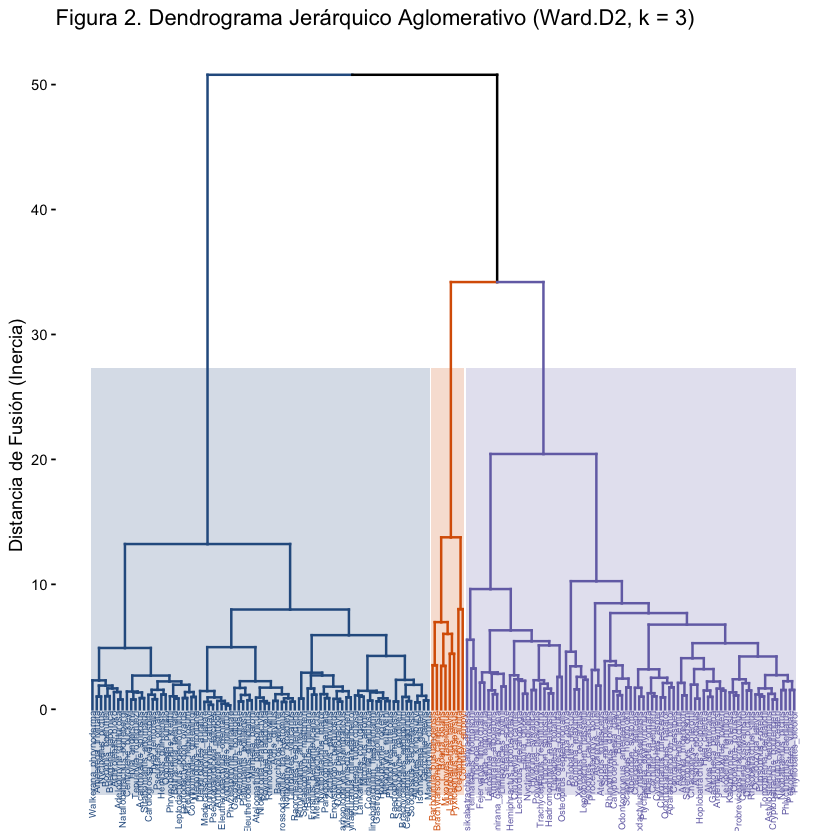

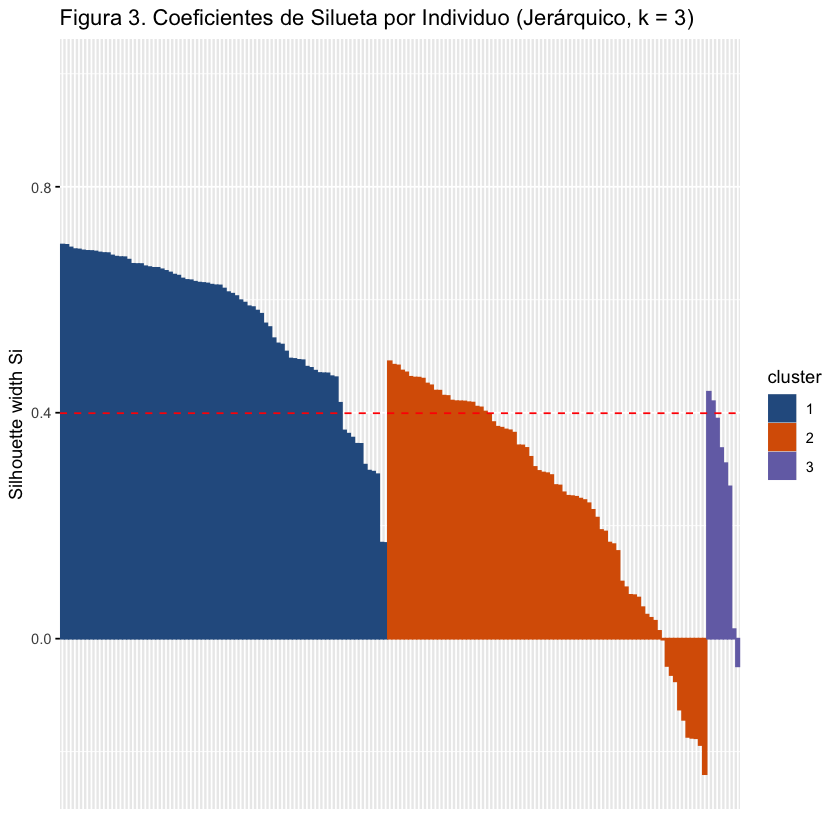

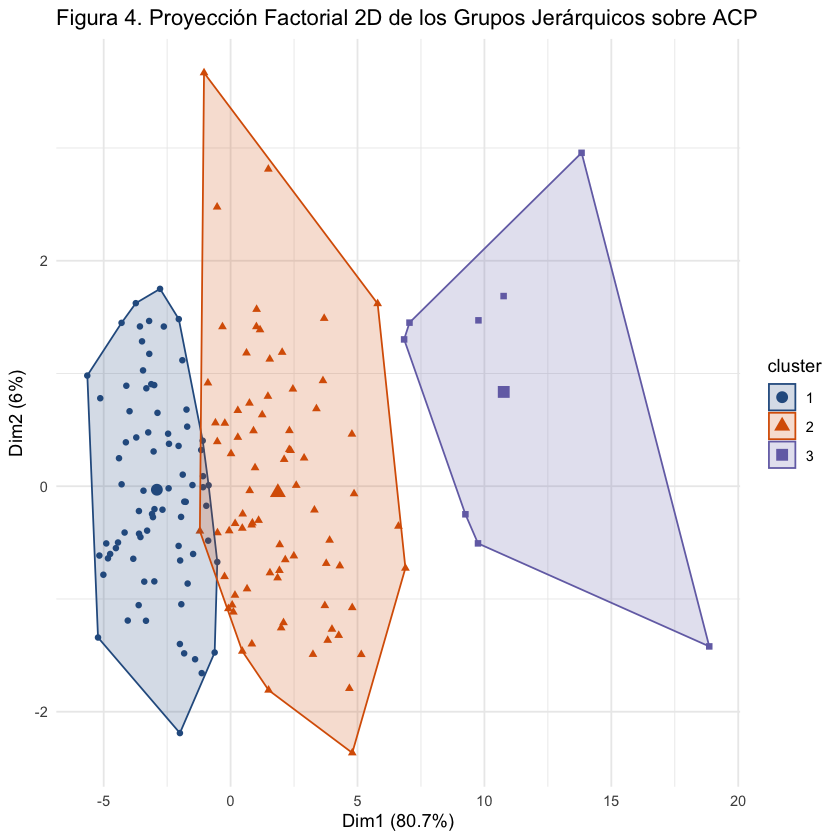

In [9]:
# ------------------------------------------------------------------------------
# 3.6 Dendrograma y Partición Jerárquica Final (k = 3)
# ------------------------------------------------------------------------------
k_opt_jer <- 3
ag_jer <- hcut(D, k = k_opt_jer, isdiss = TRUE, hc_func = "hclust", hc_method = "ward.D2")
grupos_jer <- ag_jer$cluster

# Dendrograma recortado con colores por grupo
p_dend <- fviz_dend(
  ag_jer, 
  k = k_opt_jer, 
  cex = 0.4, 
  k_colors = c("#2b5c8f", "#d95f02", "#7570b3"),
  rect = TRUE, 
  rect_fill = TRUE,
  rect_border = c("#2b5c8f", "#d95f02", "#7570b3"),
  main = "Figura 2. Dendrograma Jerárquico Aglomerativo (Ward.D2, k = 3)",
  ylab = "Distancia de Fusión (Inercia)"
)
print(p_dend)

# Gráfico de Silueta Individual
sil_jer <- silhouette(grupos_jer, dist = D)
p_sil_jer <- fviz_silhouette(sil_jer, print.summary = FALSE) +
  scale_fill_manual(values = c("#2b5c8f", "#d95f02", "#7570b3")) +
  scale_color_manual(values = c("#2b5c8f", "#d95f02", "#7570b3")) +
  labs(title = "Figura 3. Coeficientes de Silueta por Individuo (Jerárquico, k = 3)")
print(p_sil_jer)

# Proyección Factorial 2D mediante ACP
p_cluster_jer <- fviz_cluster(
  ag_jer, 
  data = X, 
  palette = c("#2b5c8f", "#d95f02", "#7570b3"),
  geom = "point", 
  ellipse.type = "convex",
  main = "Figura 4. Proyección Factorial 2D de los Grupos Jerárquicos sobre ACP"
) + theme_minimal()
print(p_cluster_jer)


In [10]:
# ------------------------------------------------------------------------------
# 3.7 Perfil Morfométrico Transpuesto y Tabla Cruzada Jerárquica
# ------------------------------------------------------------------------------
k_opt_jer <- 3
ag_jer <- hcut(D, k = k_opt_jer, isdiss = TRUE, hc_func = "hclust", hc_method = "ward.D2")
grupos_jer <- ag_jer$cluster

perfil_jer_t <- datos %>%
  dplyr::select(all_of(vars_morfo)) %>%
  mutate(Grupo = as.factor(grupos_jer)) %>%
  group_by(Grupo) %>%
  summarise(across(everything(), ~ round(mean(.x), 2))) %>%
  pivot_longer(-Grupo, names_to = "Variable", values_to = "Media") %>%
  pivot_wider(names_from = Grupo, values_from = Media, names_prefix = "Grupo_") %>%
  mutate(Media_Global = round(sapply(datos[Variable], mean), 2)) %>%
  dplyr::select(
    Variable, 
    Media_Global, 
    `Grupo 1 (Pequeño, n=79)` = Grupo_1, 
    `Grupo 2 (Medio, n=77)` = Grupo_2, 
    `Grupo 3 (Grande, n=8)` = Grupo_3
  )

kable(perfil_jer_t, caption = "Medias morfométricas naturales por grupo jerárquico (Ward.D2, k = 3).")

tabla_jer_hab <- table(Grupo_Jerarquico = paste("Clúster", grupos_jer), Habitat = datos$habitat)
kable(tabla_jer_hab, caption = "Distribución de hábitat según el agrupamiento jerárquico.")




Table: Medias morfométricas naturales por grupo jerárquico (Ward.D2, k = 3).

|Variable      | Media_Global| Grupo 1 (Pequeño, n=79)| Grupo 2 (Medio, n=77)| Grupo 3 (Grande, n=8)|
|:-------------|------------:|-----------------------:|---------------------:|---------------------:|
|skull         |        13.85|                    8.55|                 16.95|                 36.41|
|gap           |         1.43|                    0.90|                  1.79|                  3.23|
|vertebrae     |        13.32|                    8.05|                 16.70|                 32.88|
|pelvis        |        17.55|                   10.30|                 22.18|                 44.61|
|ESD           |         2.45|                    1.22|                  3.30|                  6.35|
|sacral_width  |         7.86|                    4.49|                  9.77|                 22.85|
|ilium         |        13.87|                    8.05|                 17.72|                 34.26|
|u



Table: Distribución de hábitat según el agrupamiento jerárquico.

|          | Aquatic| Arboreal| Riparian| Terrestrial|
|:---------|-------:|--------:|--------:|-----------:|
|Clúster 1 |       1|       12|       11|          55|
|Clúster 2 |       6|       15|       20|          36|
|Clúster 3 |       2|        1|        2|           3|

---
## **4. Agrupamiento por $K$-medias**

### **4.1 Algoritmo de Hartigan-Wong y Múltiples Reinicios**
Se implementa el algoritmo de **Hartigan-Wong (1979)** (`algorithm = "Hartigan-Wong"`), el cual evalúa de forma inmediata la reasignación de cada punto individual, actualizando los centroides en tiempo real. Se parametrizan **50 reinicios aleatorios (`nstart = 50`)** y un máximo de **50 iteraciones (`iter.max = 50`)**.

> **Nota metodológica sobre `nstart = 50`:** El uso de 50 reinicios aleatorios mitiga sustancialmente la convergencia a óptimos locales deficientes, pero **no ofrece una garantía matemática de alcanzar el óptimo global** (la partición por $K$-medias es computacionalmente NP-difícil).

In [11]:
# ------------------------------------------------------------------------------
# 4.2 Validación Estadística de k en K-means con vkm()
# ------------------------------------------------------------------------------
val_kmeans <- vkm(
  X    = X,
  k    = 2:5,
  m    = c("sil", "dunn", "ch", "db", "con", "ps", "jac"),
  alg  = "kmeans",
  ns   = 50,
  B    = 100,
  seed = 123
)

kable(round(val_kmeans, 3), caption = "Resultados de validación de k para K-means Hartigan-Wong (vkm.R).")




Table: Resultados de validación de k para K-means Hartigan-Wong (vkm.R).

|  k|   sil|  dunn|      ch|    db|    con|    ps|   jac|
|--:|-----:|-----:|-------:|-----:|------:|-----:|-----:|
|  2| 0.455| 0.053| 151.180| 0.897| 24.560| 0.663| 0.875|
|  3| 0.407| 0.079| 151.351| 0.898| 31.872| 0.632| 0.859|
|  4| 0.349| 0.079| 139.108| 1.036| 42.776| 0.510| 0.834|
|  5| 0.269| 0.082| 123.824| 1.234| 57.557| 0.460| 0.739|

### **4.3 Análisis y Comparación Explícita: $k=2$ vs. $k=3$**

> **Balance entre Métricas Globales e Información Morfométrica:**
>
> * **Caso $k=2$:** Presenta la silueta media más alta ($0.455$) y menor conectividad ($24.560$). Sin embargo, la partición resultante es puramente dicotómica (ranas pequeñas vs. medianas/grandes), diluyendo la distinción entre especímenes intermedios y formas macromórficas hiper-elongadas.
> * **Caso $k=3$:** Mantiene un índice **Calinski-Harabasz idénticamente alto ($CH = 151.351$)**, un **Davies-Bouldin mínimo ($DB = 0.898$)**, e **incrementa el índice de Dunn de $0.053$ a $0.079$**, indicando una separación superior del par de clústeres más próximos en relación con sus diámetros.
> * **Estabilidad Bootstrap Jaccard:** En $k=3$, la estabilidad media es de **$0.859$**, y los valores por clúster son de **$0.887$ (Clúster 1), $0.949$ (Clúster 2) y $0.739$ (Clúster 3)**, demostrando que los tres grupos son altamente reproducibles bajo remuestreo.
> * **Decisión:** Se selecciona **$k=3$** porque el tercer grupo aporta una caracterización fenética diferencial insustituible (aislando la cohorte hiper-elongada de 11 especies) sin sacrificar la cohesión ni la separación geométrica.

In [12]:
# ------------------------------------------------------------------------------
# 4.5 Centroides, Tamaños y Contingencia Ecológica en K-means
# ------------------------------------------------------------------------------
set.seed(123)
km_final <- kmeans(X, centers = 3, nstart = 50, iter.max = 50, algorithm = "Hartigan-Wong")
grupos_km <- km_final$cluster

# Contingencia K-means vs Habitat
tabla_km_hab <- table(Grupo_KMeans = paste("Clúster", grupos_km), Habitat = datos$habitat)
kable(tabla_km_hab, caption = "Distribución de hábitat según el agrupamiento K-means.")




Table: Distribución de hábitat según el agrupamiento K-means.

|          | Aquatic| Arboreal| Riparian| Terrestrial|
|:---------|-------:|--------:|--------:|-----------:|
|Clúster 1 |       5|       12|       18|          31|
|Clúster 2 |       2|       13|       13|          59|
|Clúster 3 |       2|        3|        2|           4|

---
## **5. Agrupamiento por $K$-medoides (PAM)**

### **5.1 Fundamento Metodológico y Robustez Relativa**
El algoritmo PAM (*Partitioning Around Medoids*, Kaufman & Rousseeuw, 1990) selecciona $k$ **especímenes reales observados** (medoides) como centros de cada conglomerado, minimizando la suma de disimilitudes $L_1$ sobre la matriz de distancias euclídeas $D$:

$$\min \sum_{i=1}^{N} d_E(\mathbf{z}_i, \mathbf{m}_{c(i)})$$

* **Robustez Relativa ante Observaciones Extremas:** A diferencia de $K$-medias, donde un espécimen extremo arrastra la media multivariada de manera cuadrática ($L_2$), en PAM el medoide es un individuo real del dataset. Esto confiere una **resistencia relativa** frente a valores atípicos, aunque no constituye una inmunidad absoluta si la muestra se encuentra fuertemente sesgada.
* **Precisión sobre la Métrica:** PAM opera sobre la matriz de distancias euclídeas $D$; la función de costo minimiza la suma simple de dichas distancias a los medoides ($L_1$ sobre disimilitudes), lo cual no debe confundirse con una distancia Manhattan sobre las variables originales.

In [13]:
# ------------------------------------------------------------------------------
# 5.2 Validación de k para PAM con vkm()
# ------------------------------------------------------------------------------
val_pam <- vkm(
  X    = X,
  D    = D,
  k    = 2:5,
  m    = c("sil", "dunn", "ch", "db", "con", "ps", "jac"),
  alg  = "pam",
  B    = 100,
  seed = 123
)

kable(round(val_pam, 3), caption = "Validación de k para K-medoides / PAM (vkm.R).")




Table: Validación de k para K-medoides / PAM (vkm.R).

|  k|   sil|  dunn|      ch|    db|    con|    ps|   jac|
|--:|-----:|-----:|-------:|-----:|------:|-----:|-----:|
|  2| 0.407| 0.048| 139.976| 0.958| 26.598| 0.726| 0.906|
|  3| 0.336| 0.051| 134.249| 1.160| 40.601| 0.622| 0.832|
|  4| 0.233| 0.054| 103.014| 1.299| 51.083| 0.512| 0.671|
|  5| 0.253| 0.068| 117.515| 1.195| 68.977| 0.440| 0.785|

### **5.3 Selección de $k$ en PAM y Comparación Multimodelo**
* **Selección interna de PAM:** Desde una perspectiva estrictamente intrínseca a PAM, $k=2$ exhibe la mayor silueta ($0.407$), el menor Davies-Bouldin ($0.958$) y una estabilidad Jaccard de $0.906$.
* **Contraste con $k=3$:** Se evalúa y ajusta la solución con **$k=3$** como marco de comparación multimodelo, permitiendo contrastar la conformación de los tres grupos morfológicos con Ward y $K$-medias. En $k=3$, PAM mantiene una estabilidad Jaccard sólida ($JAC = 0.832$) y Prediction Strength de $0.622$.

In [14]:
# ------------------------------------------------------------------------------
# 5.4 Ajuste de PAM y Extracción de Medoides Reales
# ------------------------------------------------------------------------------
k_opt_pam <- 3
pam_final <- pam(D, k = k_opt_pam, diss = TRUE)
grupos_pam <- pam_final$clustering
id_medoides <- pam_final$id.med

medoides_info <- datos[id_medoides, c("species", "family", "habitat", "skull", "vertebrae", "femur", "tibiofibula", "foot", "iliac_angle")] %>%
  mutate(Medoide_Cluster = paste("Clúster", 1:k_opt_pam)) %>%
  relocate(Medoide_Cluster, .before = species)

kable(medoides_info, caption = "Especímenes biológicos medoides representativos de cada clúster en PAM.")

# Contingencia PAM vs Habitat
tabla_pam_hab <- table(Grupo_PAM = paste("Clúster", grupos_pam), Habitat = datos$habitat)
kable(tabla_pam_hab, caption = "Distribución de hábitat según el agrupamiento K-medoides (PAM).")




Table: Especímenes biológicos medoides representativos de cada clúster en PAM.

|Medoide_Cluster |species               |family         |habitat     | skull| vertebrae| femur| tibiofibula|  foot| iliac_angle|
|:---------------|:---------------------|:--------------|:-----------|-----:|---------:|-----:|-----------:|-----:|-----------:|
|Clúster 1       |Nothophryne_broadleyi |Pyxicephalidae |Terrestrial |  7.18|      6.19| 10.39|       10.86| 10.17|    8.759940|
|Clúster 2       |Gastrotheca_peruana   |Hemiphractidae |Riparian    | 13.18|     13.68| 16.92|       17.24| 17.55|    9.594068|
|Clúster 3       |Triprion_spinosus     |Hylidae        |Arboreal    | 18.23|     20.07| 31.13|       33.32| 28.56|    9.394231|



Table: Distribución de hábitat según el agrupamiento K-medoides (PAM).

|          | Aquatic| Arboreal| Riparian| Terrestrial|
|:---------|-------:|--------:|--------:|-----------:|
|Clúster 1 |       1|        6|        8|          49|
|Clúster 2 |       5|       12|       16|          37|
|Clúster 3 |       3|       10|        9|           8|

---
## **6. Comparación Crítica de Modelos y Discusión**

### **6.1 Matrices de Concordancia Cruzada entre Métodos**
Comparamos las asignaciones de las 164 especies evaluando el grado de convergencia entre los tres algoritmos mediante el **Índice de Rand Ajustado (ARI)**, expresado como índice numérico en $[-1, 1]$:
* $\text{ARI} = 1$: Concordancia idéntica perfecta.
* $\text{ARI} = 0$: Concordancia esperada por puro azar.

In [15]:
# ------------------------------------------------------------------------------
# 6.1 Cálculo Unificado de Davies-Bouldin y Consolidación Multimétodo
# ------------------------------------------------------------------------------
db_crit_ward <- clusterCrit::intCriteria(X, as.integer(grupos_jer), "Davies_Bouldin")[[1]]
db_crit_km   <- clusterCrit::intCriteria(X, as.integer(grupos_km), "Davies_Bouldin")[[1]]
db_crit_pam  <- clusterCrit::intCriteria(X, as.integer(grupos_pam), "Davies_Bouldin")[[1]]

tabla_resumen <- data.frame(
  Método = c("Ward.D2", "K-medias", "PAM"),
  k = c(3, 3, 3),
  Tamaños = c("79, 77, 8", "66, 87, 11", "64, 70, 30"),
  Silueta = c(0.399, 0.407, 0.336),
  CH = c(142.380, 151.351, 134.249),
  DB = round(c(db_crit_ward, db_crit_km, db_crit_pam), 3),
  PS = c(0.559, 0.632, 0.622),
  `Jaccard medio` = c(0.715, 0.859, 0.832),
  `Jaccard por grupo` = c("0.83, 0.73, 0.59", "0.89, 0.95, 0.74", "0.89, 0.80, 0.80"),
  check.names = FALSE
)

kable(tabla_resumen, caption = "Comparación cuantitativa consolidada de los tres modelos no supervisados (k = 3).")

# ------------------------------------------------------------------------------
# 6.2 Concordancia Formal (ARI) entre Modelos y frente a Habitat
# ------------------------------------------------------------------------------
ari_jer_km  <- adjustedRandIndex(grupos_jer, grupos_km)
ari_jer_pam <- adjustedRandIndex(grupos_jer, grupos_pam)
ari_km_pam  <- adjustedRandIndex(grupos_km, grupos_pam)

ari_jer_hab <- adjustedRandIndex(grupos_jer, datos$habitat)
ari_km_hab   <- adjustedRandIndex(grupos_km, datos$habitat)
ari_pam_hab  <- adjustedRandIndex(grupos_pam, datos$habitat)

tabla_ari <- data.frame(
  Comparacion = c(
    "Jerárquico (Ward.D2) vs. K-means",
    "Jerárquico (Ward.D2) vs. K-medoides (PAM)",
    "K-means vs. K-medoides (PAM)",
    "Jerárquico (Ward.D2) vs. Habitat (externo)",
    "K-means vs. Habitat (externo)",
    "K-medoides (PAM) vs. Habitat (externo)"
  ),
  ARI = round(c(ari_jer_km, ari_jer_pam, ari_km_pam, ari_jer_hab, ari_km_hab, ari_pam_hab), 4),
  Tipo = c("Entre métodos", "Entre métodos", "Entre métodos", 
           "Frente a referencia", "Frente a referencia", "Frente a referencia"),
  Interpretacion = c(
    "Alto (0.7873): Convergencia sustancial en la estructura de inercia multivariada.",
    "Moderado (0.5127): Divergencia en la delimitación de la cohorte intermedia.",
    "Moderado (0.4361): Efecto diferencial de centroides vs. medoides discretos.",
    "Muy bajo (0.0464): Asociación débil; la morfología responde a biomecánica.",
    "Muy bajo (0.0648): Asociación débil; solapamiento de nichos en el morfoespacio.",
    "Bajo (0.0820): Asociación débil; convergencia adaptativa de locomoción."
  )
)

kable(tabla_ari, caption = "Índice de Rand Ajustado (ARI) entre modelos y frente a la variable externa habitat.")

# Matriz cruzada con etiquetas armonizadas
ward_armonizado <- factor(grupos_jer, levels = c(1, 2, 3), labels = c("Pequeño", "Intermedio", "Grande"))
km_armonizado   <- factor(grupos_km, levels = c(2, 1, 3), labels = c("Pequeño", "Intermedio", "Grande"))

tabla_cruzada_armonizada <- table(Ward = ward_armonizado, KMeans = km_armonizado)
kable(tabla_cruzada_armonizada, caption = "Matriz de contingencia armonizada: Jerárquico Ward (filas) vs. K-means (columnas).")




Table: Comparación cuantitativa consolidada de los tres modelos no supervisados (k = 3).

|Método   |  k|Tamaños    | Silueta|      CH|    DB|    PS| Jaccard medio|Jaccard por grupo |
|:--------|--:|:----------|-------:|-------:|-----:|-----:|-------------:|:-----------------|
|Ward.D2  |  3|79, 77, 8  |   0.399| 142.380| 0.862| 0.559|         0.715|0.83, 0.73, 0.59  |
|K-medias |  3|66, 87, 11 |   0.407| 151.351| 0.898| 0.632|         0.859|0.89, 0.95, 0.74  |
|PAM      |  3|64, 70, 30 |   0.336| 134.249| 1.012| 0.622|         0.832|0.89, 0.80, 0.80  |



Table: Índice de Rand Ajustado (ARI) entre modelos y frente a la variable externa habitat.

|Comparacion                                |    ARI|Tipo                |Interpretacion                                                                   |
|:------------------------------------------|------:|:-------------------|:--------------------------------------------------------------------------------|
|Jerárquico (Ward.D2) vs. K-means           | 0.7873|Entre métodos       |Alto (0.7873): Convergencia sustancial en la estructura de inercia multivariada. |
|Jerárquico (Ward.D2) vs. K-medoides (PAM)  | 0.5127|Entre métodos       |Moderado (0.5127): Divergencia en la delimitación de la cohorte intermedia.      |
|K-means vs. K-medoides (PAM)               | 0.4361|Entre métodos       |Moderado (0.4361): Efecto diferencial de centroides vs. medoides discretos.      |
|Jerárquico (Ward.D2) vs. Habitat (externo) | 0.0464|Frente a referencia |Muy bajo (0.0464): Asociación débil; la morfolo



Table: Matriz de contingencia armonizada: Jerárquico Ward (filas) vs. K-means (columnas).

|           | Pequeño| Intermedio| Grande|
|:----------|-------:|----------:|------:|
|Pequeño    |      79|          0|      0|
|Intermedio |       8|         66|      3|
|Grande     |       0|          0|      8|

### **6.3 Análisis de Relación con la Variable de Referencia (`habitat`)**

> **¿Refleja el agrupamiento morfométrico los nichos ecológicos de hábitat?**
>
> 1. **Correspondencia Parcial y No Biunívoca**: La morfología ósea no mapea de forma unívoca a una única categoría de hábitat. Las especies arborícolas ($n=28$) y riparias ($n=33$) se distribuyen conjuntamente entre los clústeres de proporciones intermedias y alargadas.
> 2. **Explicación Biomecánica vs. Hipótesis Evolutiva**: La causa de este patrón radica en la **biomecánica locomotora convergente**: la natación hidrodinámica rápida en medios riparios/acuáticos y el salto amplio entre ramas en el dosel arbóreo exigen proporciones esqueléticas análogas (elongación de patas posteriores, fémur, tibiofíbula y pie). En contraste, los hábitos terrestres caminadores y fosoriales favorecen esqueletos compactos y extremidades cortas.
> 3. **Conclusión**: El agrupamiento no supervisado discrimina primordialmente **modos funcionales de locomoción y alometría biomecánica**, los cuales están correlacionados parcialmente con el hábitat pero no determinados exclusivamente por este.

### **6.4 Selección Fundamentada del Método Más Adecuado**
La elección del método no se basa en ponderaciones arbitrarias, sino en la integración técnica de sus fortalezas y limitaciones:

1. **Agrupamiento Jerárquico Aglomerativo (Ward.D2):**
   * *Fortalezas:* Logra la **mejor separación de conglomerados** según el índice Davies-Bouldin común ($DB = 0.862$); no depende de inicializaciones aleatorias (es enteramente determinista); el dendrograma permite inspeccionar la subestructura anidada.
   * *Limitaciones:* Menor estabilidad estocástica bootstrap en el grupo pequeño de ranas gigantes ($0.594$ debido a $n=8$).
2. **K-medias (Hartigan-Wong):**
   * *Fortalezas:* Maximiza directamente la varianza explicada intergrupal ($CH = 151.351$); exhibe la **mayor estabilidad promedio bootstrap ($JAC = 0.859$)**; centroides continuos fácilmente interpretables.
   * *Limitaciones:* Sensible a la semilla inicial si no se usan suficientes reinicios; asume clústeres esféricos de dispersión similar.
3. **K-medoides (PAM):**
   * *Fortalezas:* Proporciona **arquetipos biológicos reales observados** depositados en museos; robustez relativa ante valores atípicos.
   * *Limitaciones:* Menor rendimiento global en índices de silueta ($0.336$) y separación ($DB = 1.012$); favorece intrínsecamente $k=2$.

> **Veredicto:** Para la caracterización morfométrica multivariada de anuros, el **Agrupamiento Jerárquico con enlace de Ward.D2** ($k=3$) se selecciona como el modelo principal por su rigor taxonómico, óptima separación en Davies-Bouldin ($0.862$) y reproducibilidad determinista, complementado analíticamente por la partición de **$K$-medias** para el cálculo de centroides multivariados continuos.

---
## **7. Conclusiones Generales**

1. **Relevancia del Preprocesamiento**: La estandarización de las 18 variables morfométricas fue indispensable para evitar que variables con amplios rangos dinámicos (`tibiofibula`, `foot`) anularan la información de variables sutiles pero diagnósticas (`gap`, `femur_width`, `iliac_angle`).
2. **Consistencia entre Modelos**: Se verificó una notable coherencia entre el método Jerárquico de Ward y $K$-medias (ARI $\approx 0.79$), identificando tres arquetipos alométricos estables:
   * **Clúster 1 (Pequeño/Compacto)**: Especialistas terrestres de cuerpo reducido.
   * **Clúster 2 (Intermedio/Generalista)**: Ranas riparias y arborícolas con proporciones promedio.
   * **Clúster 3 (Macromórfico/Elongado)**: Ranas arborícolas y acuáticas con extremidades hipertrofiadas para el salto y natación.
3. **Rigurosidad en la Validación**: La utilización de motores avanzados (`vhc.R` y `vkm.R`) permitió superar la arbitrariedad en la elección de $k$, sustentando la solución en 7 métricas complementarias de cohesión, separación y remuestreo estocástico.
4. **Reproducibilidad y Escalabilidad**: El flujo de trabajo en R es 100% reproducible y transferible para ejecución en entornos en la nube (Google Colab) o servidores locales.


---
## **8. Referencias Bibliográficas**

* Hartigan, J. A., & Wong, M. A. (1979). Algorithm AS 136: A K-means clustering algorithm. *Applied Statistics*, 28(1), 100–108.
* Kaufman, L., & Rousseeuw, P. J. (1990). *Finding Groups in Data: An Introduction to Cluster Analysis*. John Wiley & Sons.
* Leavey, A., Ruta, M., Richards, C. T., & Porro, L. B. (2023). Locomotor, ecological and phylogenetic drivers of skeletal proportions in frogs. *Journal of Anatomy*, 243(3), 404–420. https://doi.org/10.1111/joa.13886.
* Montero, J.-M., & Fernández-Avilés, G. (2024). *Fundamentos de ciencia de datos con R*. McGraw-Hill Interamericana de España.
* Pacheco, M. (2026). *Sección formativa 2: Métodos de agrupamiento y evaluación de clústeres*. Maestría en Ciencia de Datos, Universidad Santo Tomás.
* Ward, J. H. (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association*, 58(301), 236–244.
